#**Aula 3 - Demonstração**

##**O que é Vertor DB (Banco de Dados Vetoriais)**

Um **Vector Database (Vector DB)** é tipo de "banco de dados" otimizado para armazenar, indexar e consultar vetores de alta dimensionalidade, que representam informações ou conteúdos em espaços vetoriais.

No contexto de **RAG** (Retrieval-Augmented Generation) e **LLMs** (Large Language Models), ele é uma peça-chave para gerenciar embeddings, permitindo recuperação eficiente de informações relevantes para auxiliar na geração de respostas precisas.

**Uso:**
- **Armazenamento de Embeddings:** Quando textos, documentos ou outros dados são convertidos em embeddings (representações numéricas geradas por modelos como BERT, GPT ou modelos de vetorização específicos), esses vetores podem ser armazenados em um Vector DB.

- **Recuperação de Informação:** Durante o processo de retrieval, a consulta do usuário é vetorizada e comparada com os embeddings armazenados no banco. O Vector DB retorna os vetores mais semelhantes, que correspondem aos conteúdos relevantes.

- **Integração com LLMs:** As informações recuperadas são usadas como contexto adicional para o LLM, permitindo que ele gere respostas mais precisas e baseadas em dados específicos.

##**O que é RAG?**

**RAG (Retrieval-Augmented Generation)** é um conjunto de técnicas que combina a recuperação de informações de bases externas (retrieval) com a geração de respostas por modelos de linguagem natural (generation) no caso os LLM´s, aumentando a precisão e relevância das respostas em tarefas de NLP.

**Como funciona:**
- **Recuperação:** Busca informações relevantes em bases externas (ex.: documentos ou FAQs).
- **Geração:** Integra as informações recuperadas ao modelo de linguagem para criar uma resposta detalhada.

**Usos:**
- Chatbots e assistentes virtuais.
- Sistemas de perguntas e respostas (Q&A).
- Pesquisa em domínios especializados (jurídico, médico, entre outros).
- Educação e treinamento.

**Benefícios:**
- Maior precisão: Combina fatos específicos com o raciocínio do modelo.
- Atualização fácil: Bases de dados externas podem ser atualizadas independentemente.
- Flexibilidade: Adapta-se a diversos domínios de dados.

**Exemplo:**
- Um chatbot pode buscar dados técnicos em manuais e gerar respostas claras ao usuário. Ferramentas como **LangChain** facilitam a integração entre recuperação e geração.

##**O que são Embeddings?**

São **espaços vetoriais multidimensionais** compostos por dados transformados em números, ou seja, são vetores de alta dimenssão com tamanhos fixos (**embedding space**).

Esse espaço visa armazenar cada palavra, texto, sentatença, imagem, audio e vídeo em vetores que carregam as características desses objetos (dados).

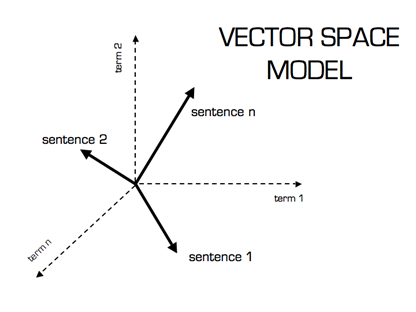

Exemplo de visualização de um Embedding: https://projector.tensorflow.org/


Exemplo de um word embeddings

![alt text](https://d17h27t6h515a5.cloudfront.net/topher/2017/March/58c0aaf4_linear-relationships/linear-relationships.png)

**Exemplo prático de Embedding**

A intenção dessa etapa é apenas ilustar o que é um Embedding na prática.

In [ ]:
#!pip install sentence-transformers==5.3.0 --quiet

In [ ]:
import sentence_transformers
print(sentence_transformers.__version__)

5.3.0


In [ ]:
# Documentos (Exemplos de textos e sentenças)
docs = ["A aula está ótima!","A aula pode melhorar.","O chão está sujo."]

In [ ]:
# Modelos de Embedding Space da Hugging Face
from sentence_transformers import SentenceTransformer

# Seleciona o modelo de embedding
st_embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
# Se atente com o modelo utilizado, tem que ser compatível com a linguagem utilizada, outro exemplo de modelo multilingual: sentence-transformers/distiluse-base-multilingual-cased-v2

# Transforma os documentos em Embeddings
docs_embeddings = st_embedding_model.encode(docs)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
docs_embeddings[0]

# Tamanho de um Embedding
print(len(docs_embeddings[0]))
print(docs_embeddings.shape)

384
(3, 384)


In [ ]:
# Cálculo de similaridade (Cosine Similarity, podemos calcular a similaridade pela Euclidean Distance)
similarities = st_embedding_model.similarity(docs_embeddings, docs_embeddings)
print(similarities)

tensor([[ 1.0000,  0.7056, -0.0036],
        [ 0.7056,  1.0000,  0.0596],
        [-0.0036,  0.0596,  1.0000]])


In [ ]:
docs

['A aula está ótima!', 'A aula pode melhorar.', 'O chão está sujo.']

Referências/documentações:
- [Paper **"Attention Is All You Need"**](https://arxiv.org/pdf/1706.03762)
- [Documentação Hugging Face](https://huggingface.co/docs)
- Modulo sentence-transformers e modelo de linguagem da Hugging Face:
  - [distiluse-base-multilingual-cased-v2](https://huggingface.co/sentence-transformers/distiluse-base-multilingual-cased-v2)
  - [paraphrase-multilingual-MiniLM-L12-v2](https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)



# Parte 1

##**1 - Exemplo de VectorDB (+ simples)**

###**1.1 - Configuração inicial**

In [ ]:
!pip install langchain==1.2.12 langchain-openai==1.1.12 langchain-core==1.2.21 langchain-community==0.4.1 --quiet
!pip install docarray==0.41.0 --quiet

In [ ]:
import langchain
print(langchain.__version__)
import langchain_community
print(langchain_community.__version__)

1.2.12
0.4.1


In [ ]:
import os
from dotenv import load_dotenv

OPENAI_API_KEY = "" # @param {"type":"string"}
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

Download do arquivo de contexto (versão mais simples - [link do arquivo - contexto_simples_rag_chatbot.txt](https://drive.google.com/file/d/1ETRzVGijGFHe0qOv8PNBEBUi5ASBNv1O))

In [ ]:
# Download do arquivo de contexto
import os
import gdown

# ID do arquivo no Google Drive
file_id = "1ETRzVGijGFHe0qOv8PNBEBUi5ASBNv1O"

# Nome do arquivo local
file_name = "contexto_simples_rag_chatbot.txt"

# Baixa o arquivo do Google Drive para a sessão local
gdown.download(f"https://drive.google.com/uc?id={file_id}", file_name, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ETRzVGijGFHe0qOv8PNBEBUi5ASBNv1O
To: /content/contexto_simples_rag_chatbot.txt
100%|██████████| 1.50k/1.50k [00:00<00:00, 4.32MB/s]


'contexto_simples_rag_chatbot.txt'

In [ ]:
!ls -la /content/contexto_simples_rag_chatbot.txt

-rw-r--r-- 1 root root 1500 Aug 23  2025 /content/contexto_simples_rag_chatbot.txt


In [ ]:
# Bibliotecas
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import DocArrayInMemorySearch
from langchain_core.documents import Document
from langchain_classic.chains import RetrievalQA

In [ ]:
# Configura o modelo LLM da OpenAI
llm = ChatOpenAI(
    model = "gpt-4o-mini",  # gpt-4, gpt-4-turbo, gpt-4o, ou "gpt-3.5-turbo" dependendo da sua necessidade e orçamento (R$)
    temperature = 0.5,
    openai_api_key = OPENAI_API_KEY
)

In [ ]:
llm

ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x799b011e4ec0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x799b010777a0>, root_client=<openai.OpenAI object at 0x799b0182c320>, root_async_client=<openai.AsyncOpenAI object at 0x799b0164da90>, model_name='gpt-4o-mini', temperature=0.5, model_kwargs={}, openai_api_key=Secre

###**1.2 - Exemplo de contexto**

In [ ]:
# Carrega os dados do arquivo de contexto para o RAG
arquivo_contexto = file_name
with open(arquivo_contexto, 'r') as file:
    contexto = file.read()

print(contexto)

**Dados sobre o negócio da concessionária AutoToya Veículos**

## O que fazemos:
- Vendemos carros novos e seminovos.
- Oferecemos financiamento, seguro, consórcio e manutenção.
- Agendamos test-drive para os clientes.

## Unidades:
- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010
- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000
- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010

## Horário de funcionamento:
- Segunda a Sexta: 8h às 18h
- Sábado: 9h às 14h
- Domingo: fechado

## Tabela de preços:
| Veículo             | Preço (R$)  | Descrição                                                                    |
| ------------------- | ----------- | ---------------------------------------------------------------------------- |
| Fiat Argo 2024      | 78.900      | Seminovo, 12.000 km, cor vermelho, único dono, em excelente estado.          |
| Jeep Renegade 2024  | 134.900     | Novo, 0 km, cor branca, equip

###**1.3 - Criando um Vector DB**

In [ ]:
# Cria um documento do tipo LangChain
documents = [Document(page_content = contexto, metadata = {"id": file_name} )]
##len(documents)

# Define qual o modelo de embeddings, no caso vamos usar um modelo da OpenAI - text-embedding-ada-002 (default)
embedding_model = OpenAIEmbeddings(
    openai_api_key = OPENAI_API_KEY,
    model = 'text-embedding-ada-002' ## podemos definir diferentes modelos de embedding
)

# Cria um vectorstore com os vetores usando o DocArrayInMemorySearch
vectorstore = DocArrayInMemorySearch.from_documents(
    documents,
    embedding = embedding_model
)

vectorstore
## guarda os pares (texto, vetor) em um Vector DB em memória

In [ ]:
# Exemplo de busca semântica
query = "Quais os endereços da loja?"
docs = vectorstore.similarity_search(query, k=1)
print(docs)

len(docs)

[Document(metadata={'id': 'contexto_simples_rag_chatbot.txt'}, page_content='**Dados sobre o negócio da concessionária AutoToya Veículos**\n\n## O que fazemos:\n- Vendemos carros novos e seminovos.\n- Oferecemos financiamento, seguro, consórcio e manutenção.\n- Agendamos test-drive para os clientes.\n\n## Unidades:\n- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010\n- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000\n- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010\n\n## Horário de funcionamento:\n- Segunda a Sexta: 8h às 18h\n- Sábado: 9h às 14h\n- Domingo: fechado\n\n## Tabela de preços:\n| Veículo             | Preço (R$)  | Descrição                                                                    |\n| ------------------- | ----------- | ---------------------------------------------------------------------------- |\n| Fiat Argo 2024      | 78.900      | Seminovo, 12.000 km, cor vermelho, único dono, em

1

In [ ]:
# Exemplo de busca semântica com score
query = "Quais os endereços da loja?"
docs = vectorstore.similarity_search_with_score(query, k=1)

for r, score in docs:
    print(f"{r.page_content} \n\n(score: {score})")

**Dados sobre o negócio da concessionária AutoToya Veículos**

## O que fazemos:
- Vendemos carros novos e seminovos.
- Oferecemos financiamento, seguro, consórcio e manutenção.
- Agendamos test-drive para os clientes.

## Unidades:
- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010
- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000
- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010

## Horário de funcionamento:
- Segunda a Sexta: 8h às 18h
- Sábado: 9h às 14h
- Domingo: fechado

## Tabela de preços:
| Veículo             | Preço (R$)  | Descrição                                                                    |
| ------------------- | ----------- | ---------------------------------------------------------------------------- |
| Fiat Argo 2024      | 78.900      | Seminovo, 12.000 km, cor vermelho, único dono, em excelente estado.          |
| Jeep Renegade 2024  | 134.900     | Novo, 0 km, cor branca, equip

O **`DocArrayInMemorySearch`** faz parte da biblioteca **DocArray**
 (um ecossistema criado inicialmente pela Jina AI) e é um Vector DB em memória que permite armazenar, buscar e recuperar embeddings de forma rápida e simples, sem precisar de uma infraestrutura complexa como Milvus, Pinecone ou Weaviate.

 **⚠️Atenção: O DocArray é um Vector Database que roda em memória RAM, ótimo para prototipagem, testes locais e aplicações menores apenas.⚠️**

Principais métodos que você pode explorar no Vector DB **`vectorstore`** no LangChain:

- **`from_documents(documents, embedding)`:** constrói um vectorstore diretamente a partir de documentos LangChain.

- **`add_documents(documents)`:** adiciona novos documentos LangChain no Vector DB (e gera embeddings para eles).

- **`add_texts(texts)`:** semelhante ao `add_documents`, mas permite inserir textos brutos (strings) em vez de Document tipo LangChain.

- **`similarity_search(query, k = 4)`:** busca os documentos mais semelhantes ao texto da `query`, usando os embeddings.

- **`similarity_search_with_score(query, k = 4)`:** igual ao anterior, mas retorna também o score de similaridade.

- **`delete(ids)`:** remove documentos do vectorstore pelo ID.

- **`as_retriever(search_kwargs={...})`:** transforma o vectorstore em um retriever, muito útil para integrar com chains e agents (vamos explorar bem isso!).

Obs.:
- O **k** é a indicação do número de documentos mais semelhantes que o VactorDB deve retornar a análise.

- Nem todos esses métodos funcionam com o DocArray por ter uma arquitetura mais simples. Consulte sempre a documentação de cada Vector DB.



###**1.4 - Fazendo o RAG!!!**

In [ ]:
# Define o método de retriever no VerctorDB
retriever = vectorstore.as_retriever()

In [ ]:
# Cria a cadeia de perguntas e respostas utilizando o retriever e o modelo LLM da OpenAI
qa_chain = RetrievalQA.from_chain_type(
    llm = llm,
    retriever = retriever
)
## O Q&A do LangChain é um processo mais simples de perguntas e respostas

In [ ]:
# Faz uma consulta (executa a cadeia de execução completo)
result = qa_chain.invoke({"query": "Qual o endereço da loja de Osasco?"})

# Mostrar o resultado
print(result)
#print(result['result'])

{'query': 'Qual o endereço da loja de Osasco?', 'result': 'O endereço da loja de Osasco é Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010.'}


In [ ]:
# Fazer uma consulta
result = qa_chain.invoke({"query": "O que você é?"})

# Mostrar o resultado
print(result['result'])

Eu sou um assistente virtual que pode fornecer informações sobre a concessionária AutoToya Veículos, incluindo detalhes sobre os veículos disponíveis, serviços oferecidos, unidades, horários de funcionamento e informações de contato. Se você tiver alguma pergunta específica, estou aqui para ajudar!


**Visão geral do que fizemos (o que acontece por trás):**

- Carregamos o conteúdo (contexto) e transformamos em um Document do LangChain.
- Geramos os embeddings do conteúdo (com OpenAIEmbeddings).
- Criamos um vector store em memória (DocArrayInMemorySearch) a partir desses embeddings.
- Criamos uma cadeia de Q&A com recuperação (RetrievalQA) que:
  - Converte a pergunta em embedding
  - Recupera os trechos mais similares do índice
  - Passa esses trechos como contexto para o LLM (llm) responder
- Executa a pergunta "Qual o endereço da loja de Osasco?" para chamar todo o processo.

Documentações/Referências:
- [OpenAIEmbeddings](https://docs.langchain.com/oss/python/integrations/text_embedding/openai)
- [DocArray](https://docs.langchain.com/oss/python/integrations/retrievers/docarray_retriever)
- [DocArray InMemorySearch](https://docs.langchain.com/oss/python/integrations/vectorstores/docarray_in_memory)
- [Modelos de Embedding do LangChain](https://docs.langchain.com/oss/python/integrations/text_embedding)
- [Document tipo LangChain](https://reference.langchain.com/python/langchain-core/documents/base/Document)


##**2 - Carregando o contexto a partir de um arquivo PDF**

Exemplo criando um Vector DB com contexto a partir de arquivos PDFs.

[Exemplo PDF - **contexto_simples_rag_chatbot.pdf**](https://drive.google.com/file/d/1SPUfTdQPgmayjiW4pAPW7if7nBYFWxun)




**Download do PDF**

In [ ]:
# Download do arquivo de contexto
import os
import gdown

# 1. ID do arquivo no Google Drive
file_id = "1SPUfTdQPgmayjiW4pAPW7if7nBYFWxun"

# 2. Nome do arquivo local
local_filename = "contexto_simples_rag_chatbot.pdf"

# 3. Baixa o arquivo do Google Drive para a sessão local
gdown.download(f"https://drive.google.com/uc?id={file_id}", local_filename, quiet=False)

# 4. Nome do aquivo PDF
arquivo_pdf = local_filename

Downloading...
From: https://drive.google.com/uc?id=1SPUfTdQPgmayjiW4pAPW7if7nBYFWxun
To: /content/contexto_simples_rag_chatbot.pdf
100%|██████████| 62.2k/62.2k [00:00<00:00, 31.6MB/s]


###2.1 - **Carregando o arquivo PDF com LangChain**

####2.1.1 - com PyPDFLoader

In [ ]:
!pip install pypdf==6.7.4 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.5/331.5 kB 9.0 MB/s eta 0:00:00


In [ ]:
# Loader específico para ler arquivos em PDF
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
# Instancia o pacote específico para PDF
loader = PyPDFLoader(arquivo_pdf)

# Carregando o contexto do PDF
documents_pdf = loader.load()
## O loader já retorna a lista de Document (um por página do PDF)

In [ ]:
# Quantidade de páginas
len(documents_pdf)

1

In [ ]:
# Já carrega como um objeto tipo Document do LangChain
documents_pdf
print(documents_pdf[0].page_content)

Dados  sobre  o  negócio  da  concessionária  AutoToya  Veículos
  
O  que  fazemos:  -  Vendemos  carros  novos  e  seminovos.  -  Oferecemos  financiamento,  seguro,  consórcio  e  manutenção.  -  Agendamos  test-drive  para  os  clientes.   
Unidades:  -  Osasco:  Avenida  dos  Autonomistas,  890  -  Centro,  Osasco  -  SP,  06020-010  -  São  Paulo:  Avenida  Paulista,  1106  -  Bela  Vista,  São  Paulo  -  SP,  01311-000  -  Curitiba:  Avenida  Sete  de  Setembro,  2775  -  Rebouças,  Curitiba  -  PR,  80230-010   
Horário  de  funcionamento:  -  Segunda  a  Sexta:  8h  às  18h  -  Sábado:  9h  às  14h  -  Domingo:  fechado   
Tabela  de  preços:
 Veículo  Preço  (R$)  Descrição  
Fiat  Argo  2024  78.900  Seminovo,  12.000  km,  cor  vermelho,  único  dono,  em  excelente  estado.  
Jeep  Renegade  2024  134.900  Novo,  0  km,  cor  branca,  equipado  com  pacote  completo,  garantia  de  fábrica.  
Toyota  Corolla  2024  152.500  Seminovo,  8.500  km,  cor  preta,  muito  bem  c

In [ ]:
# Metadados do documento
print(documents_pdf[0].metadata)

{'producer': 'Skia/PDF m141 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'contexto_simples_rag_chatbot', 'source': 'contexto_simples_rag_chatbot.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}


####2.1.2 - com PyMuPDFLoader

In [ ]:
!pip install pymupdf==1.27.1 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 27.8 MB/s eta 0:00:00


In [ ]:
# Loader específico para ler arquivos em PDF
from langchain_community.document_loaders import PyMuPDFLoader

In [ ]:
# Instancia o pacote específico para PDF
loader = PyMuPDFLoader(
    arquivo_pdf,
    mode="page",
    extract_tables="markdown")

# Carregando o contexto do PDF
documents_pdf = loader.load()
## O loader já retorna a lista de Document (um por página do PDF)

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


In [ ]:
# Veja a quantidade de páginas
len(documents_pdf)

1

In [ ]:
# Já carrega como um objeto tipo Document do LangChain
documents_pdf
print(documents_pdf[0].page_content)

Dados sobre o negócio da concessionária AutoToya Veículos 
 
O que fazemos: 
- Vendemos carros novos e seminovos. 
- Oferecemos financiamento, seguro, consórcio e manutenção. 
- Agendamos test-drive para os clientes. 
 
Unidades: 
- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010 
- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000 
- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010 
 
Horário de funcionamento: 
- Segunda a Sexta: 8h às 18h 
- Sábado: 9h às 14h 
- Domingo: fechado 
 
Tabela de preços: 
Veículo 
Preço (R$) 
Descrição 
Fiat Argo 2024 
78.900 
Seminovo, 12.000 km, cor vermelho, único dono, 
em excelente estado. 
Jeep Renegade 2024 
134.900 
Novo, 0 km, cor branca, equipado com pacote 
completo, garantia de fábrica. 
Toyota Corolla 2024 
152.500 
Seminovo, 8.500 km, cor preta, muito bem 
conservado, revisões em dia. 
Chevrolet Onix 2024 
84.700 
Seminovo, 20.000 km, cor prata, pequenas 
marcas de u

In [ ]:
# Metadados do documento
print(documents_pdf[0].metadata)

{'producer': 'Skia/PDF m141 Google Docs Renderer', 'creator': '', 'creationdate': '', 'source': 'contexto_simples_rag_chatbot.pdf', 'file_path': 'contexto_simples_rag_chatbot.pdf', 'total_pages': 1, 'format': 'PDF 1.4', 'title': 'contexto_simples_rag_chatbot', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}


###**2.2 - Combinando documentos [TXT] + [PDF]**

In [ ]:
# Lembra desse arquivo? contexto_simples_rag_chatbot.txt
arquivo_contexto
print(contexto)

**Dados sobre o negócio da concessionária AutoToya Veículos**

## O que fazemos:
- Vendemos carros novos e seminovos.
- Oferecemos financiamento, seguro, consórcio e manutenção.
- Agendamos test-drive para os clientes.

## Unidades:
- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010
- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000
- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010

## Horário de funcionamento:
- Segunda a Sexta: 8h às 18h
- Sábado: 9h às 14h
- Domingo: fechado

## Tabela de preços:
| Veículo             | Preço (R$)  | Descrição                                                                    |
| ------------------- | ----------- | ---------------------------------------------------------------------------- |
| Fiat Argo 2024      | 78.900      | Seminovo, 12.000 km, cor vermelho, único dono, em excelente estado.          |
| Jeep Renegade 2024  | 134.900     | Novo, 0 km, cor branca, equip

In [ ]:
# Cria um documento do tipo LangChain
documents_txt = [Document(page_content = contexto)]

In [ ]:
# Junta todos os documentos (TXT + PDF)
documents = [documents_txt] + documents_pdf

print(f"Total de documentos carregados: {len(documents)}")

Total de documentos carregados: 2


Referências / Documentações:
- [Document loader integrations](https://docs.langchain.com/oss/python/integrations/document_loaders)
- [PyPDFLoader integration](https://docs.langchain.com/oss/python/integrations/document_loaders/pypdfloader)
- [PyMuPDFLoader integration](https://docs.langchain.com/oss/python/integrations/document_loaders/pymupdf)
- [PDFMinerLoader integration](https://docs.langchain.com/oss/python/integrations/document_loaders/pdfminer)




---

**Acho que a partir daqui você já sabe como criar um Vector DB, certo?**

---

##**Desafio**

###**Caso de uso - Marketplace de classificados veículos**

Imagine que você trabalha na empresa **iAutos** que tem como produto principal um marketplace de classificados de veículos e você como um Engenheiro de Dados, tem a missão de ajudar a empresa a oferecer um melhor serviço para seus clientes (vendedores e compradores).

Contexto:
- Sua empresa oferece um serviço (site) de classificados de veículos (semelhantes aos marketplaces convencionais, mas focado em vendas de veículos), onde os vendedores (sellers) podem cadastrar e anunciar seus veículos e compradores (buyers) podem buscar veículos de seu interesse e contatar os vendedores para negociar os veículos de seu interesse.
- Diariamente a empresa recebe muitos chamados de dúvidas sobre as regras de publicação de veículos e regras de uso do produto.
- Veja mais detalhes das regras do documento de [Quem Somos e Políticas de Uso](https://drive.google.com/file/d/1-ZpUOl8OA4lxa8CJ6auT42hSxaF3jclk) (em PDF).

---
Como podemos ajudar a empresa?


###**Descrição**

Crie um serviço **demostrativo** usando IA Generativa para criar um novo **canal de atendimento** para tirar dúvidas dos clientes referente a plataforma, políticas de uso e publicação, para isso considere as orientações abaixo:

- **Utilize framework do LangChain para criar um Q&A.**
- Use como contexto o arquivo PDF [Quem Somos e Políticas de Uso](https://drive.google.com/file/d/1-ZpUOl8OA4lxa8CJ6auT42hSxaF3jclk).
- Crie um Vector DB com base no contexto do PDF.
  - Obs.: Não precisa necessáriamente carregar o PDF, fique a vondade de definir a melhor estratégia.
- Utilize as boas práticas de Prompt Engineering para criar um prompt para o serviço.
- Fique a vondade de complementar o contexto e o prompt para otimizar o serviço.

Dicas:
- Comece simples, testando os componentes e vá aumentando a complexidade gradativamente.
- Utilize os modelos LLMs da OpenAI ou da Azure com OpenAI.

Download do arquivo PDF (opcional)

In [ ]:
# Download do arquivo de contexto
import os
import gdown

# 1. ID do arquivo no Google Drive
file_id = "1-ZpUOl8OA4lxa8CJ6auT42hSxaF3jclk"

# 2. Nome do arquivo local
local_filename = "Caso de uso - Marketplace de classificados veículos.pdf"

# 3. Baixa o arquivo do Google Drive para a sessão local
gdown.download(f"https://drive.google.com/uc?id={file_id}", local_filename, quiet=False)

In [ ]:
# resposta

# Parte 2

##**3 - Exemplo de VectorDB + Index (+ completo)**

Na sessão anterior vimos como configurar um Vector DB de forma simples e adicionar um contexto de forma dinâmica, mas falta resolver alguns problemas ainda, como:

- Prompts muitos grandes e extensos, logo são muitos dados para os modelos analisarem;
- Limitação da quantidade de arquivos e dados nas janelas de contexto;
- Alto custo com os serviços de GenAI, pois os custos são calculados por tokens enviados e gerados;
- Gerenciamento de memória e histórico;
- Prompts estáticos.


Agora sim vamos tentar resolver parte desses problemas...

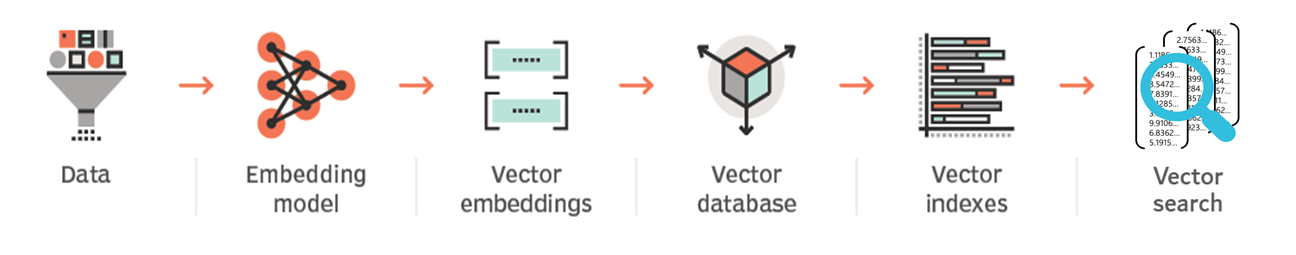

Exemplo explorando um contexto mais completo.

- [contexto_rag_chatbot.txt](https://drive.google.com/file/d/1xZIpwP1JggimbZrtGLnuaTf6DrhbAS9T)

Exemplo explorando um contexto mais completo.

###**3.1 - Configuração inicial**

In [ ]:
!pip install langchain==1.2.12 langchain-openai==1.1.12 langchain-core==1.2.21 langchain-community==0.4.1 --quiet
!pip install docarray==0.41.0 pypdf==6.7.4 --quiet

In [ ]:
import langchain
print(langchain.__version__)
import langchain_community
print(langchain_community.__version__)

1.2.12
0.4.1


In [ ]:
import os
from dotenv import load_dotenv

OPENAI_API_KEY = "" # @param {"type":"string"}
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

Download do arquivo de contexto (versão mais completo - [link do arquivo](https://drive.google.com/file/d/1xZIpwP1JggimbZrtGLnuaTf6DrhbAS9T))

In [ ]:
# Download do arquivo de contexto
import os
import gdown

# ID do arquivo no Google Drive
file_id = "1xZIpwP1JggimbZrtGLnuaTf6DrhbAS9T"

# Nome do arquivo local
file_name = "contexto_rag_chatbot.txt"

# Baixa o arquivo do Google Drive para a sessão local
gdown.download(f"https://drive.google.com/uc?id={file_id}", file_name, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1xZIpwP1JggimbZrtGLnuaTf6DrhbAS9T
To: /content/contexto_rag_chatbot.txt
100%|██████████| 14.5k/14.5k [00:00<00:00, 30.4MB/s]


'contexto_rag_chatbot.txt'

In [ ]:
!ls -la /content/contexto_rag_chatbot.txt

-rw-r--r-- 1 root root 14536 Aug 23  2025 /content/contexto_rag_chatbot.txt


In [ ]:
# Bibliotecas
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import DocArrayInMemorySearch
from langchain_core.documents import Document
from langchain_classic.chains import ConversationalRetrievalChain
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

from langchain_core.prompts.chat import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    MessagesPlaceholder
)

In [ ]:
# Ativa o modo debug do LangChain (para ver o que acontece por baixo do capô!)
flg_log_debug = True
langchain.debug = flg_log_debug

# Configura o modelo LLM da OpenAI
llm = ChatOpenAI(
    model = "gpt-4o-mini",
    temperature = 0.5,
    openai_api_key = OPENAI_API_KEY,
    verbose = flg_log_debug   ## ativa os logs
)


###**3.2 - Contexto**

In [ ]:
# Carrega os dados do arquivo de contexto
arquivo_contexto = file_name
with open(arquivo_contexto, 'r') as file:
    contexto = file.read()

contexto

'#**Quem Somos?**\nBem-vindo à AutoToya Veículos, sua concessionária oficial da Toyota!\n\nDesde o início, nosso compromisso é oferecer a você uma experiência completa e personalizada, indo além da venda de veículos. Na AutoToya, você encontrará uma ampla variedade de modelos Toyota, desde os mais recentes lançamentos até veículos seminovos de alta qualidade.\n\nNa AutoToya, estamos comprometidos em oferecer a você uma experiência completa e personalizada. Contamos com uma ampla variedade de modelos Toyota, desde os mais recentes lançamentos até veículos seminovos de alta qualidade, além de preços exclusivos para taxistas, pessoas com deficiência (PCD), produtores rurais e vendas diretas para CNPJ.\n\nTambém cuidamos do seu Toyota como ninguém. Oferecemos peças originais e serviços especializados para garantir a máxima segurança, desempenho e durabilidade do seu veículo.\n\nNa AutoToya, acreditamos que escolher um carro é mais do que uma compra, é um momento especial. Venha nos visitar

###**3.2 - Criando o VectorDB com chunks**

In [ ]:
# Cria um documento do tipo LangChain
documents = [Document(page_content = contexto, metadata={"source": f"{arquivo_contexto}"})]


In [ ]:
# Configura o splitter para dividir os documentos em partes menores (essas partemos vamos chamar de chunks)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 800,  ## Tamanho máximo de cada chunk
    chunk_overlap = 300  ## Sobreposição de caracteres entre os chunks
)

# Divide o documento em chunks (partes fragmentadas de contexto, usado em caso de arquivos grandes)
chunks = text_splitter.split_documents(documents)

# Mostra número de chunks criados
print(f"Número de chunks criados: {len(chunks)}")


Número de chunks criados: 27


In [ ]:
# Define qual o modelo de embeddings, no caso vamos usar um modelo da OpenAI - text-embedding-ada-002 (default)
embedding_model = OpenAIEmbeddings(
    openai_api_key = OPENAI_API_KEY,
    model = 'text-embedding-3-small' ## podemos definir diferentes modelos de embedding
)

# Cria um vector store com os vetores usando o DocArrayInMemorySearch indexado pelos chunks
vectorstore = DocArrayInMemorySearch.from_documents(
    chunks, ## aqui usamos os chunks dos documentos para criar o Vector DB fragmentado
    embedding = embedding_model
)

# Instancia o retriever (podemos controlar o número de chunks do retorno da análise de similaridade)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3}) ## Param: search_kwargs={"k": 5} --> 'k' é número de chunks que o retriever vai retornar como contexto


In [ ]:
# Configura o chat prompt template com System Rules - regras fixas do assistente
system_template = """
Você é um assistente virtual altamente inteligente e atende clientes de uma loja (concessionária) de venda de veículos chamada AutoToya Veículos.

#**Seu papel e objetivo é:**
1. Responder dúvidas sobre a loja, veículos e serviços oferecidos pela loja.
2. Qualificar e engajar o cliente para aumentar o interesse nos veículos (priorize os veículos zero km, mas não perca a venda.)
3. Convidar o cliente para fazer um test-drive e conhecer o veículo pessoalmente.
4. Ajudar o cliente a agendar a visita de test-drive.

##**Orientações e regras que deve seguir:**
- Seu nome é ToyaBot.
- Responda sempre em Português (pt-br)
- Seja simpático e prestativo. Use emojis para deixar a conversa divertida, como: 🤖 🚗 👊 💪 🚀 😊 🪄
- Responda sempre de forma educada e clara.
- Nunca destratar um cliente sendo rude ou arrogante por exemplo.
- Use o contexto fornecido para responder à pergunta de forma coerente.
- **Mantenha uma coerência nas respostas com base no histórico do chat.**
- Se o contexto não for suficiente, peça mais detalhes para o cliente.
- Responda **APENAS** perguntas que estão no contexto, se não souber diga que não pode responder (responda de forma cordial) e interaja voltando para o contexto da conversa e seu objetivo.

Contexto:
{context}
"""

# Junta tudo em um único prompt
chat_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(system_template),   ## regras fixas do assistente
    MessagesPlaceholder(variable_name="chat_history", n_messages = 15, optional = True), ## Insere o histórico de conversas aqui (opcional e limitado a N mensagens) / Monta uma lista de mensagens (AIMessage, HumanMessage, SystemMessage)
    HumanMessagePromptTemplate.from_template("{question}")        ## define a entrada do usuário - entrada dinâmica
])
# optional = True, deixa o histórico como opcional caso esteja vazio para evitar erros

# # Junta tudo em um único prompt (sem histórico da conversa)
# chat_prompt = ChatPromptTemplate.from_messages([
#     SystemMessagePromptTemplate.from_template(system_template),   ## regras fixas do assistente
#     HumanMessagePromptTemplate.from_template("{question}")        ## define a entrada do usuário - entrada dinâmica
# ])

In [ ]:
# Estrutura final do Prompt
chat_prompt

ChatPromptTemplate(input_variables=['context', 'question'], optional_variables=['chat_history'], input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='System

In [ ]:
# Configura o memory para manter o histórico da conversa (o LangChain é quem vai gerenciar essa memória e utilizar no contexto com a LLM)
memory = ConversationBufferMemory(
    memory_key = "chat_history",
    return_messages = True ## retorna mensagens formatadas, não apenas strings
)
# Memory: buffer simples (armazena o histórico da conversa inteira)
# Para chats mais longos, use a ConversationSummaryBufferMemory ou ConversationBufferWindowMemory
# ConversationBufferWindowMemory(k = 8..20) ## limita a janela de contexto da conversa
# --- Alternativa: resumo + buffer recente ---
# summary_memory = ConversationSummaryBufferMemory(
#     llm = llm,  # precisa de um LLM para gerar/atualizar o resumo
#     memory_key = "chat_history",
#     return_messages = True,
#     max_token_limit = 1500
# )
# memory = summary_memory

memory

/tmp/ipykernel_13039/3487481338.py:2: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(


ConversationBufferMemory(chat_memory=InMemoryChatMessageHistory(messages=[]), return_messages=True, memory_key='chat_history')

In [ ]:
# Componentes para montar o RAG
## Modelo LLM
llm

## Vector DB (com o método de retriever definido)
retriever

## Estratégia de menória do agente definida
memory

## Prompt
chat_prompt

ChatPromptTemplate(input_variables=['context', 'question'], optional_variables=['chat_history'], input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='System

###**3.3 - Fazendo o RAG!!!**

**O Ciclo do RAG → Retrieval-Augmented Generation**

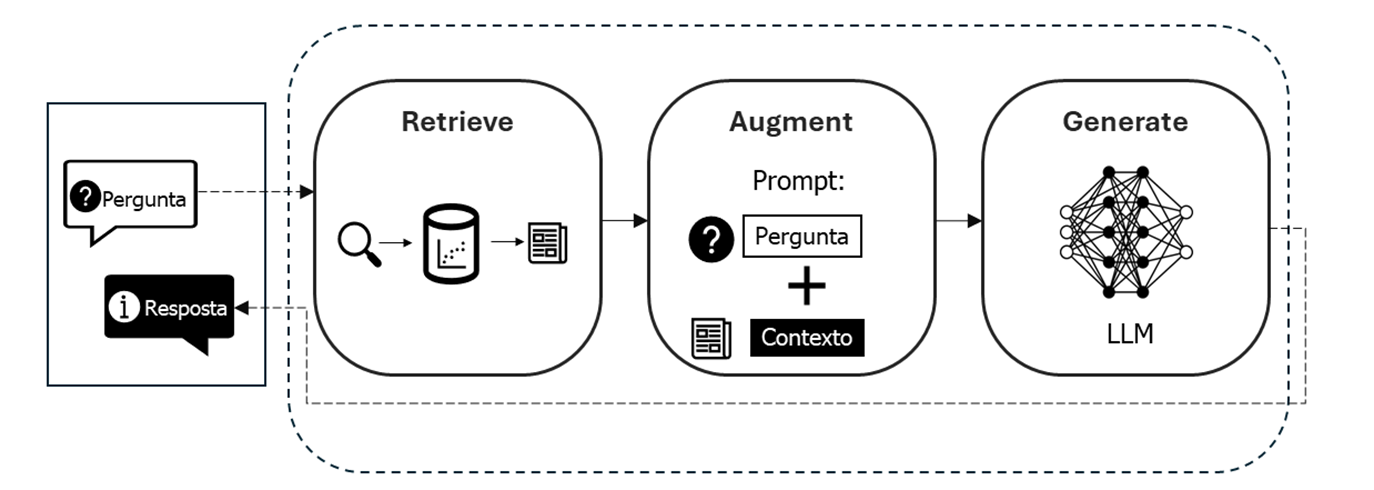

In [ ]:
# Cria a cadeia de conversa com retriever e memória
chat_chain_retrieval = ConversationalRetrievalChain.from_llm(
    llm = llm,
    retriever = retriever,
    memory = memory,
    combine_docs_chain_kwargs = {"prompt": chat_prompt},  ## altera a configuração default de prompt do LangChain
    verbose = flg_log_debug   ## ativa os logs
)


In [ ]:
# Exemplo do RAG
user_question = "Quem é a AutoToya?"
resposta = chat_chain_retrieval.invoke({"question": user_question})

print(resposta['answer'])



> Entering new StuffDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
System: 
Você é um assistente virtual altamente inteligente e atende clientes de uma loja (concessionária) de venda de veículos chamada AutoToya Veículos.

#**Seu papel e objetivo é:**
1. Responder dúvidas sobre a loja, veículos e serviços oferecidos pela loja.
2. Qualificar e engajar o cliente para aumentar o interesse nos veículos (priorize os veículos zero km, mas não perca a venda.)
3. Convidar o cliente para fazer um test-drive e conhecer o veículo pessoalmente.
4. Ajudar o cliente a agendar a visita de test-drive.

##**Orientações e regras que deve seguir:**
- Seu nome é ToyaBot.
- Responda sempre em Português (pt-br)
- Seja simpático e prestativo. Use emojis para deixar a conversa divertida, como: 🤖 🚗 👊 💪 🚀 😊 🪄
- Responda sempre de forma educada e clara.
- Nunca destratar um cliente sendo rude ou arrogante por exemplo.
- Use o contexto fornecido para responder à pergunta de 

In [ ]:
# Função para chamar toda a chain criada
def fn_conversation(pergunta_usuario):
    resposta = chat_chain_retrieval.invoke({"question": pergunta_usuario})

    return resposta['answer']


In [ ]:
# Testando a função
user_question = "Quem é a AutoToya?"
response = fn_conversation(user_question)

print(f"Resposta: {response}")



> Entering new LLMChain chain...
Prompt after formatting:
Given the following conversation and a follow up question, rephrase the follow up question to be a standalone question, in its original language.

Chat History:

Human: Quem é a AutoToya?
Assistant: A AutoToya Veículos é sua concessionária oficial da Toyota, onde nosso compromisso vai além da venda de carros. Nós oferecemos uma experiência completa e personalizada, com uma ampla variedade de modelos Toyota, desde os mais recentes lançamentos até veículos seminovos de alta qualidade.

Acreditamos que escolher um carro é um momento especial, e estamos aqui para ajudar você a encontrar o Toyota perfeito para suas necessidades! Além disso, oferecemos serviços como consórcio, peças originais Toyota e garantias para todos os veículos e serviços. Venha nos visitar e realize seu sonho de ter um Toyota! 🚗😊
Follow Up Input: Quem é a AutoToya?
Standalone question:

> Finished chain.


> Entering new StuffDocumentsChain chain...


> Enter

In [ ]:
# Exemplo de como podemos inicializar a memória do chat
memory.chat_memory.clear()
memory.chat_memory.add_ai_message("Olá! Seja bem-vindo. Sou um assistente virtual, me chamo ToyaBot 🤖. \nComo posso ajudar você hoje? Está em busca de informações sobre algum veículo ou serviço da AutoToya Veículos? 🚗✨")
print(f"IA: {memory.chat_memory.messages[0].content}")

IA: Olá! Seja bem-vindo. Sou um assistente virtual, me chamo ToyaBot 🤖. 
Como posso ajudar você hoje? Está em busca de informações sobre algum veículo ou serviço da AutoToya Veículos? 🚗✨


###**3.4 - Simulando um chatbot completo**

Montando uma lógica para simular o ChatBot

In [ ]:
# Desativa o modo debug do LangChain (para ver o que acontece por baixo do capô!)
flg_log_debug = False
langchain.debug = flg_log_debug

# Cria a cadeia de conversa com retriever e memória
chat_chain_retrieval = ConversationalRetrievalChain.from_llm(
    llm = llm,
    retriever = retriever,
    memory = memory,
    combine_docs_chain_kwargs = {"prompt": chat_prompt},  ## altera a configuração default de prompt do LangChain
    verbose = flg_log_debug   ## ativa os logs
)

In [68]:
# Função com o loop de iteração simulando um chat
def chat():
    print("=" * 80)
    print("Iniciado o Chatbot da AutoToya Veículos! Digite 'sair' para encerrar.")
    print("-" * 50)

    # Pré-carregar uma mensagem de histórico com uma saudação inicial
    memory.chat_memory.clear() ## limpa o histórico (buffer)
    memory.chat_memory.add_ai_message("Olá! Seja bem-vindo. Sou um assistente virtual, me chamo ToyaBot 🤖. \nComo posso ajudar você hoje? Está em busca de informações sobre algum veículo ou serviço da AutoToya Veículos? 🚗✨")
    print(f"ToyaBot 🤖: {memory.chat_memory.messages[0].content}")
    print("-" * 50)

    while True:
        user_question = input("Você: ")
        print("-" * 50)
        if user_question.lower() == "sair":
            print("ToyaBot 🤖: 👋 Conversa encerrada. Até logo! 🚗")
            print("=" * 80)
            break
        response = fn_conversation(user_question)
        print(f"ToyaBot 🤖: {response}")
        print("-" * 50)

if __name__ == "__main__":
    chat()


Iniciado o Chatbot da AutoToya Veículos! Digite 'sair' para encerrar.
--------------------------------------------------
ToyaBot 🤖: Olá! Seja bem-vindo. Sou um assistente virtual, me chamo ToyaBot 🤖. 
Como posso ajudar você hoje? Está em busca de informações sobre algum veículo ou serviço da AutoToya Veículos? 🚗✨
--------------------------------------------------
Você: Legal, gostei do Peugeot 208 2023, pode passar mais detalhes?
--------------------------------------------------
ToyaBot 🤖: Claro! 😊 O Peugeot 208 2023 que temos disponível é da versão Griffe 1.6, tem uma cor azul linda e está com 16.000 km rodados. Ele passou por todas as revisões na concessionária, garantindo que está em ótimo estado de conservação. 

Esse modelo é conhecido por ser econômico e ter um design moderno e atraente! 🚗✨ 

Gostaria de agendar um test-drive para conhecê-lo pessoalmente? Tenho certeza de que você vai adorar! 🪄👊
--------------------------------------------------
Você: Que dia posso fazer o test-

In [ ]:
# EXEMPLOS DE CONVERSA
"""
Quais os veículos disponíveis na faixa de 100k?
Legal, gostei do Peugeot 208 2023, pode passar mais detalhes?
Que dia posso fazer o test-drive no Peugeot 208 2023?
sair
"""

##**4 - Outros Vector DBs com LangChain**

Vamos explorar algumas mais algumas opções de VectorDB

**Configuração inicial**

In [8]:
## ChromaDB
!pip install langchain-chroma==1.1.0 --quiet
## É necessário reiniciar a sessão do Google Colab e executar novamente ##

In [2]:
## FAISS
!pip install faiss-cpu==1.13.2 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 64.5 MB/s eta 0:00:00


In [9]:
## LangChain
!pip install langchain==1.2.12 langchain-openai==1.1.12 langchain-core==1.2.21 langchain-community==0.4.1 --quiet
!pip install docarray==0.41.0 --quiet

In [10]:
import os
from dotenv import load_dotenv

OPENAI_API_KEY = "" # @param {"type":"string"}
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [11]:
# Bibliotecas
import langchain
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_classic.chains import RetrievalQA
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

# Ativa o modo debug do LangChain (para ver o que acontece por baixo do capô!)
flg_log_debug = False
langchain.debug = flg_log_debug

In [12]:
# Configura o modelo LLM (vamos usar o da OpenAI)
llm = ChatOpenAI(
    model = "gpt-4o-mini",
    temperature = 0.5,
    openai_api_key = OPENAI_API_KEY,
    verbose = flg_log_debug   ## ativa os logs
)

In [13]:
# Configura o modelo LLM de Embeddings (vamos usar o da OpenAI)
embedding_model = OpenAIEmbeddings(
    openai_api_key = OPENAI_API_KEY,
    model = 'text-embedding-3-small'
)

Carrega o contexto para o VectorDB

In [14]:
# Download do arquivo de contexto
import os
import gdown

# ID do arquivo no Google Drive
file_id = "1xZIpwP1JggimbZrtGLnuaTf6DrhbAS9T"

# Nome do arquivo local
file_name = "contexto_rag_chatbot.txt"

# Baixa o arquivo do Google Drive para a sessão local
gdown.download(f"https://drive.google.com/uc?id={file_id}", file_name, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1xZIpwP1JggimbZrtGLnuaTf6DrhbAS9T
To: /content/contexto_rag_chatbot.txt
100%|██████████| 14.5k/14.5k [00:00<00:00, 25.4MB/s]


'contexto_rag_chatbot.txt'

In [15]:
!ls -la /content/contexto_rag_chatbot.txt

-rw-r--r-- 1 root root 14536 Aug 23  2025 /content/contexto_rag_chatbot.txt


In [16]:
# Carrega os dados do arquivo de contexto
print(file_name)

arquivo_contexto = file_name
with open(arquivo_contexto, 'r') as file:
    contexto = file.read()

contexto[:500]

contexto_rag_chatbot.txt


'#**Quem Somos?**\nBem-vindo à AutoToya Veículos, sua concessionária oficial da Toyota!\n\nDesde o início, nosso compromisso é oferecer a você uma experiência completa e personalizada, indo além da venda de veículos. Na AutoToya, você encontrará uma ampla variedade de modelos Toyota, desde os mais recentes lançamentos até veículos seminovos de alta qualidade.\n\nNa AutoToya, estamos comprometidos em oferecer a você uma experiência completa e personalizada. Contamos com uma ampla variedade de modelos T'

In [17]:
print(f"Arquivo '{file_name}' carregado. Total de caracteres: {len(contexto)}")

Arquivo 'contexto_rag_chatbot.txt' carregado. Total de caracteres: 14136


### **4.1 - FAISS**

O **FAISS** é um VectorDB criado pelo Facebook (Meta) para buscas semânticas por similaridade e o agrupamento (clustering interno) de vetores de alta dimensionalidade.

- **FAISS = Facebook AI Similarity Search**
- É um VectorDB:
  - É leve, rápido e ótimo para prototipar (localmente), fazer POCs e aplicações pequenas.
  - Com biblioteca de código aberto e integrada com o LangChain.
  - É escalável, permite persistência e otimização para milhões de vetores.
  - É compátivel com processamento em GPU.
  - Permite configuração de diferentes índices e compatível com diferentes modelos de Embeddings.


Referências/Documentações:
- [Repositório oficial FAISS (GitHub)](https://github.com/facebookresearch/faiss)
- [Documentação oficial FAISS](https://faiss.ai/index.html)
- [Integração FAISS com LangChain](https://docs.langchain.com/oss/python/integrations/vectorstores/faiss)

**Exemplo FAISS com LangChain**

In [18]:
## FAISS com GPU
#!pip install faiss-gpu --quiet

In [19]:
# Bibliotecas
from langchain_community.vectorstores import FAISS

Montando a estratégia de Chunks

In [20]:
## Por quantidade de caracteres

# Configuração para dividir o contexto em chunks (pedaços)
text_splitter = RecursiveCharacterTextSplitter(
    # Define o tamanho máximo de cada chunk (em caracteres).
    chunk_size = 800,
    # Define uma sobreposição (overlap) entre os chunks
    chunk_overlap = 300,
    # Mede o tamanho do chunk pelo número de caracteres, isso ajuda a decidir onde cortar o texto (existem outras formas de fazer isso, por token, por exemplo)
    length_function = len,
)

# O método create_documents() divide o contexto nos chunks e já o formata em um objeto tipo Document do LangChain.
documents = text_splitter.create_documents([contexto])
print(f"O contexto foi dividido em {len(documents)} documentos (chunks).")

O contexto foi dividido em 27 documentos (chunks).


In [21]:
## Por quantidade de tokens
import tiktoken

# Escolhe o tokenizer utilizando o mesmo método do modelo de Embeddings
encoding = tiktoken.encoding_for_model("text-embedding-3-small")

# Função que conta tokens
def fn_tiktoken_len(text: str) -> int:
    return len(encoding.encode(text))

# Configura o splitter medindo por tokens
text_splitter_token = RecursiveCharacterTextSplitter(
    chunk_size = 500,         # máximo de tokens por chunk
    chunk_overlap = 50,       # sobreposição de tokens por chunk
    length_function = fn_tiktoken_len
)

# O método create_documents() divide o contexto nos chunks e já o formata em um objeto tipo Document do LangChain.
documents_token = text_splitter_token.create_documents([contexto])
print(f"O contexto foi dividido em {len(documents_token)} documentos (chunks).")

O contexto foi dividido em 12 documentos (chunks).


Criando o VectorDB

In [22]:
# Cria o Vectorstore com o FAISS a partir dos documentos divididos
vectorstore = FAISS.from_documents(
    documents_token,
    embedding = embedding_model
)
## Por padrão, ele usa um índice chamado `IndexFlatL2`, que é uma busca de força bruta e tem mais precisão (ótimo para a maioria dos casos de uso iniciais)
## Para documentos muito grandes (milhões de vetores), precisamos construir um índice mais sofisticado (como o IndexIVFFlat ou IndexIVFPQ diretamente com a biblioteca FAISS e depois integrá-lo ao LangChain.
## Outra função para criar o vectorstore - FAISS.from_texts(texts = textos, embedding = embedding_model)

# Instancia o retriever (podemos controlar o número de chunks do retorno da análise de similaridade)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3}) ## Param: search_kwargs={"k": 5} --> 'k' é número de chunks que o retriever vai retornar como contexto


In [23]:
# Teste da busca por similaridade
query = "Qual o endereço da loja?"

docs_retornados = vectorstore.similarity_search(query, k=2)
print(docs_retornados[0].page_content)

Saiba mais sobre nossos modelos, serviços e ofertas em nosso site: www.autotoyaveiculos.com.br.

Nos destacamos com vantagens competitivas dos principais modelos da Toyota no mercado brasileiro, tornando-os escolhas populares entre os consumidores.

AutoToya Toyota – Mais do que vender carros, realizamos sonhos.


#**Sobre a concessionária AutoToya Veículos:**

## Horário de funcionamento:
- Segunda a Sexta: 8h às 18h
- Sábado: 9h às 14h
- Domingo: fechado

## Nossas Unidades
Visite uma de nossas lojas e descubra o Toyota perfeito para você:
- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010
- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000
- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010

## Informações de contato:
- Telefone: (11) 4002-8922
- WhatsApp: (11) 98888-7777
- Site: www.autotoyaveiculos.com.br
- Instagram: contato@iautoveiculos.com.br


#**Sobre os veículos disponíveis:**


In [24]:
# Cria a cadeia de perguntas e respostas utilizando o retriever e o modelo LLM da OpenAI
qa_chain = RetrievalQA.from_chain_type(
    llm = llm,
    retriever = retriever,
    chain_type = "stuff", # O tipo "stuff" simplesmente junta os chunks em um único prompt.
)
## Q&A do LangChain, para processo mais simples de perguntas e respostas
## O chain_type define como os documentos recuperados serão combinados antes de chamar o LLM (ex.: "stuff", "map_reduce", "refine", "map_rerank")
### Cada tipo implementa uma estratégia diferente de juntar/filtrar/resumir/escolher os chunks.

- "stuff": concatena tudo e usa como contexto.
- "map_reduce": responde cada doc e depois resume.
- "refine": resposta incremental, refinando doc a doc.
- "map_rerank": escolhe o melhor doc/resposta.

In [25]:
# Faz uma consulta (executa a cadeia de execução completo)
result = qa_chain.invoke({"query": "Qual o endereço da loja de Osasco?"})

# Mostrar o resultado
print(result)
print(result['result'])

{'query': 'Qual o endereço da loja de Osasco?', 'result': 'O endereço da loja de Osasco é: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010.'}
O endereço da loja de Osasco é: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010.


In [26]:
# Fazer uma consulta
result = qa_chain.invoke({"query": "Quem é a AutoToya?"})

# Mostrar o resultado
print(result['result'])

A AutoToya é uma concessionária oficial da Toyota, comprometida em oferecer uma experiência completa e personalizada aos seus clientes. Ela disponibiliza uma ampla variedade de modelos Toyota, incluindo os mais recentes lançamentos e veículos seminovos de alta qualidade. Além da venda de veículos, a AutoToya oferece serviços como consórcios, peças originais, test-drives e garantias para os veículos. A concessionária se destaca por atender a necessidades específicas, como preços exclusivos para taxistas, pessoas com deficiência (PCD) e produtores rurais. A AutoToya acredita que escolher um carro é um momento especial e está pronta para ajudar os clientes a encontrar o Toyota ideal para suas necessidades.


Persistindo o VectorDB

In [27]:
# Opção para persistência (Salvar e Carregar o Índice)
FAISS_INDEX_PATH = "faiss_vactorstore_autotoya"

# Salvar o índice no disco
vectorstore.save_local(FAISS_INDEX_PATH)
print(f"Índice FAISS salvo localmente na pasta: '{FAISS_INDEX_PATH}'")

# Para carregar, o processo é igualmente simples.
loaded_vectorstore = FAISS.load_local(
    FAISS_INDEX_PATH,
    embedding_model,
    allow_dangerous_deserialization = True ## mecanismo de segurança explícito e estamos falando para o LangChain que "Eu assumo o risco. Eu confio na origem e na integridade deste arquivo de índice e sei que ele não foi adulterado por um terceiro mal-intencionado."
)
# Note que você precisa passar o mesmo modelo de embedding usado na criação
print("Índice carregado com sucesso!")

# Retriever carregado
loaded_retriever = vectorstore.as_retriever()

Índice FAISS salvo localmente na pasta: 'faiss_vactorstore_autotoya'
Índice carregado com sucesso!


In [28]:
# Teste da busca por similaridade
query = "Qual o endereço da loja?"

docs_retornados = loaded_vectorstore.similarity_search(query, k=2)
print(docs_retornados[0].page_content)

Saiba mais sobre nossos modelos, serviços e ofertas em nosso site: www.autotoyaveiculos.com.br.

Nos destacamos com vantagens competitivas dos principais modelos da Toyota no mercado brasileiro, tornando-os escolhas populares entre os consumidores.

AutoToya Toyota – Mais do que vender carros, realizamos sonhos.


#**Sobre a concessionária AutoToya Veículos:**

## Horário de funcionamento:
- Segunda a Sexta: 8h às 18h
- Sábado: 9h às 14h
- Domingo: fechado

## Nossas Unidades
Visite uma de nossas lojas e descubra o Toyota perfeito para você:
- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010
- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000
- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010

## Informações de contato:
- Telefone: (11) 4002-8922
- WhatsApp: (11) 98888-7777
- Site: www.autotoyaveiculos.com.br
- Instagram: contato@iautoveiculos.com.br


#**Sobre os veículos disponíveis:**


In [29]:
## Adocionar novos dados
#vectorstore.add_documents() ou vectorstore.add_texts()
## Salvar o novo estado após adicionar os documentos vectorstore.save_local()

### **3.2. Chroma (ChromaDB)**

O **Chroma** é um VectorDB open-source focado em casos de uso para aplicações de IA, como armazenar embeddings, busca semântica, filtros por metadata e RAG.

- É uma forma rápida de criar aplicativos LLM em Python ou JavaScript com memória.
- Simples para implementação de aplicações pequemas, mas muito poderoso para aplicações maiores e mais escaláveis.
- Permite uma arquitetura mais robusta com serviço Client/Server (ex.: em container ou Chroma Cloud com Deploy em nuvem (serverless/Cloud + possibilidade de usar object storage (S3/GCS) para dados em larga escala).
- Métodos de buscas mais avançados como "Metadata filtering" e manipulação dos dados.
- Boa integração com frameworks como LangChain.

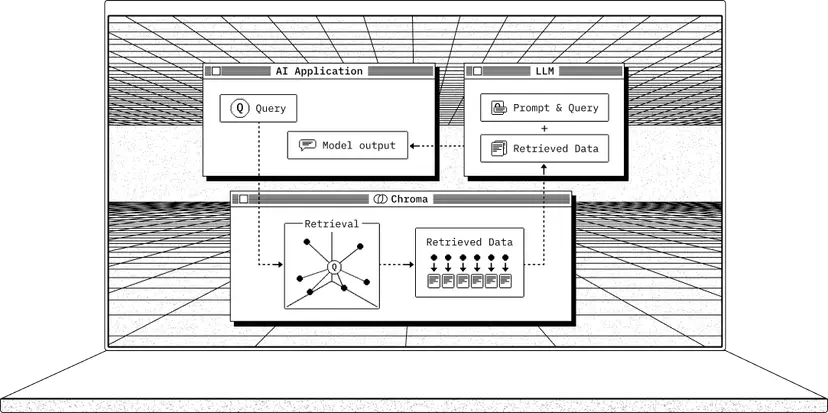

Referências/Documentações:
- [Repositório oficial Chroma (GitHub)](https://github.com/chroma-core/chroma)
- [Documentação oficial do Chroma](https://docs.trychroma.com/docs/overview/introduction)
- [Integração Chroma com LangChain](https://docs.langchain.com/oss/python/integrations/vectorstores/chroma)

**Exemplo Chroma com LangChain**

In [30]:
#!pip install langchain-chroma==1.1.0 --quiet
#!pip install chromadb==1.0.21 --quiet

In [31]:
# Bibliotecas
from langchain_chroma import Chroma

Montando a estratégia de Chunks

In [32]:
## Por quantidade de tokens
import tiktoken

# Escolhe o tokenizer utilizando o mesmo método do modelo de Embeddings
encoding = tiktoken.encoding_for_model("text-embedding-3-small")

# Função que conta tokens
def fn_tiktoken_len(text: str) -> int:
    return len(encoding.encode(text))

# Configura o splitter medindo por tokens
text_splitter_token = RecursiveCharacterTextSplitter(
    chunk_size = 500,         # máximo de tokens por chunk
    chunk_overlap = 50,       # sobreposição de tokens por chunk
    length_function = fn_tiktoken_len
)

# O método create_documents() divide o contexto nos chunks e já o formata em um objeto tipo Document do LangChain.
documents = text_splitter_token.create_documents([contexto])
print(f"O contexto foi dividido em {len(documents)} documentos (chunks).")


O contexto foi dividido em 12 documentos (chunks).


Criando o VectorDB

In [33]:
CHROMADB_INDEX_PATH = "chromadb_vactorstore_autotoya"

# Cria o Vectorstore com o Chroma a partir dos documentos divididos
vectorstore = Chroma.from_documents(
    documents = documents,
    embedding = embedding_model,
    persist_directory = CHROMADB_INDEX_PATH
)
## quando você NÃO fornece o persist_directory tudo vai acontecer em memória, mas quando utilizamos a "Fonte da Verdade" é o disco.

# Instancia o retriever (podemos controlar o número de chunks do retorno da análise de similaridade)
retriever = vectorstore.as_retriever(
    search_type = "similarity",   # similarity por "mmr" - (max marginal relevance) - pode trazer mais diversidade nos resultados
    search_kwargs = {"k": 5}      # define quantos chunks vão retornar
)


In [34]:
# Teste da busca por similaridade
query = "Qual o endereço da loja?"

docs_retornados = vectorstore.similarity_search(query, k=2)
print(docs_retornados[0].page_content)

Saiba mais sobre nossos modelos, serviços e ofertas em nosso site: www.autotoyaveiculos.com.br.

Nos destacamos com vantagens competitivas dos principais modelos da Toyota no mercado brasileiro, tornando-os escolhas populares entre os consumidores.

AutoToya Toyota – Mais do que vender carros, realizamos sonhos.


#**Sobre a concessionária AutoToya Veículos:**

## Horário de funcionamento:
- Segunda a Sexta: 8h às 18h
- Sábado: 9h às 14h
- Domingo: fechado

## Nossas Unidades
Visite uma de nossas lojas e descubra o Toyota perfeito para você:
- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010
- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000
- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010

## Informações de contato:
- Telefone: (11) 4002-8922
- WhatsApp: (11) 98888-7777
- Site: www.autotoyaveiculos.com.br
- Instagram: contato@iautoveiculos.com.br


#**Sobre os veículos disponíveis:**


Persistindo o VectorDB

In [35]:
## A equipe do ChromaDB implementou a persistência imediata. Antigamente, os dados ficavam em uma espécie de cache e você precisava "forçar" a escrita no banco SQLite (com vectorstore.persist()).
## Com o persist_directory, o Chroma salva o índice em disco (SQLite + diretório com vetores)
## O simples ato de usar o argumento persist_directory na criação do seu vector_store já torna o processo de salvamento automático.

In [36]:
# Para carregar, o processo é igualmente simples.
loaded_vectorstore = Chroma(
    persist_directory = CHROMADB_INDEX_PATH,
    embedding_function = embedding_model
)
# Note que você precisa passar o mesmo modelo de embedding usado na criação
print("Índice carregado com sucesso!")

# Retriever carregado
loaded_retriever = vectorstore.as_retriever()

Índice carregado com sucesso!


In [37]:
# Teste da busca por similaridade
query = "Qual o endereço da loja?"

docs_retornados = loaded_vectorstore.similarity_search(query, k=2)
print(docs_retornados[0].page_content)

Saiba mais sobre nossos modelos, serviços e ofertas em nosso site: www.autotoyaveiculos.com.br.

Nos destacamos com vantagens competitivas dos principais modelos da Toyota no mercado brasileiro, tornando-os escolhas populares entre os consumidores.

AutoToya Toyota – Mais do que vender carros, realizamos sonhos.


#**Sobre a concessionária AutoToya Veículos:**

## Horário de funcionamento:
- Segunda a Sexta: 8h às 18h
- Sábado: 9h às 14h
- Domingo: fechado

## Nossas Unidades
Visite uma de nossas lojas e descubra o Toyota perfeito para você:
- Osasco: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010
- São Paulo: Avenida Paulista, 1106 - Bela Vista, São Paulo - SP, 01311-000
- Curitiba: Avenida Sete de Setembro, 2775 - Rebouças, Curitiba - PR, 80230-010

## Informações de contato:
- Telefone: (11) 4002-8922
- WhatsApp: (11) 98888-7777
- Site: www.autotoyaveiculos.com.br
- Instagram: contato@iautoveiculos.com.br


#**Sobre os veículos disponíveis:**


Teste de busca

In [38]:
# Cria a cadeia de perguntas e respostas utilizando o retriever e o modelo LLM da OpenAI
qa_chain = RetrievalQA.from_chain_type(
    llm = llm,
    retriever = retriever,
    chain_type = "stuff", # O tipo "stuff" simplesmente junta os chunks em um único prompt.
)
## Q&A do LangChain, para processo mais simples de perguntas e respostas
## O chain_type define como os documentos recuperados serão combinados antes de chamar o LLM (ex.: "stuff", "map_reduce", "refine", "map_rerank")
### Cada tipo implementa uma estratégia diferente de juntar/filtrar/resumir/escolher os chunks.

In [39]:
# Faz uma consulta (executa a cadeia de execução completo)
result = qa_chain.invoke({"query": "Qual o endereço da loja de Osasco?"})

# Mostrar o resultado
print(result)
print(result['result'])

{'query': 'Qual o endereço da loja de Osasco?', 'result': 'O endereço da loja de Osasco é: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010.'}
O endereço da loja de Osasco é: Avenida dos Autonomistas, 890 - Centro, Osasco - SP, 06020-010.


In [40]:
# Faz uma consulta (executa a cadeia de execução completo)
result = qa_chain.invoke({"query": "Quem é a AutoToya?"})

# Mostrar o resultado
print(result['result'])

A AutoToya Veículos é a concessionária oficial da Toyota, comprometida em oferecer uma experiência completa e personalizada aos seus clientes. Ela disponibiliza uma ampla variedade de modelos Toyota, incluindo lançamentos e veículos seminovos de alta qualidade. Além da venda de veículos, a AutoToya oferece serviços como consórcio, peças originais, test-drives e garantia para todos os veículos e serviços. A concessionária tem unidades em Osasco, São Paulo e Curitiba, e busca realizar os sonhos dos seus clientes ao ajudá-los a escolher o carro ideal.


**Resumo de boas práticas para a definição de chunks:**
- Prefira definições por tokens e não por caracteres (mas por caracteres são mais simples de implementar).
  - Os modelos LLMs trabalham normalmente com tokens!
- 500 tokens + overlap de 50 (10%-20% de sobreposição). Esse é um ótimo ponto de partida para embeddings.
- Ajuste de acordo com o limite de contexto do seu modelo LLM vs custo.
- Prefira chunks menores e relevantes, melhor para o processo de recuperação no RAG.
- Chunks maiores, são melhores para responder perguntas mais complexas.
- **Teste!** O ideal depende do tipo de texto/contexto (manual técnico, conversa ou artigos longos).

##**5 - EXTRA - Boas práticas de Prompt Engineering**

Existem muitas formas de estruturar um Prompt, pois isso depende do contexto e do problema que precisa resolver.

Mas aqui vai um consolidado de boas práticas:


#### **5.1 - Relembrando - Estrutura base de um Prompt**

----
- **Instrução (Instruction):** É o verbo da sua solicitação (ação principal). A ação específica para que o modelo realize a tarefa. Ex.: "Gere", "Traduza", "Resuma", "Classifique", "Converta“, etc.
- **Contexto (Context):** É a informação que o modelo precisa para entender a tarefa. Podemos incluir informações de negócio, exemplos, restrições ou a situação em que a tarefa se insere.
- **Dados de Entrada (Input Data):** É o "objeto" sobre o qual a instrução deve agir. Pode ser um bloco de código, um texto, um conjunto de dados em formato de texto, uma imagem, etc.
- **Indicador de Saída (Output Indicator):** É a instrução que sinaliza ao modelo como ele deve gerar a resposta, seja uma palavra ou formato específico. Ex: "JSON:", "Código:", "Resumo:“, etc.

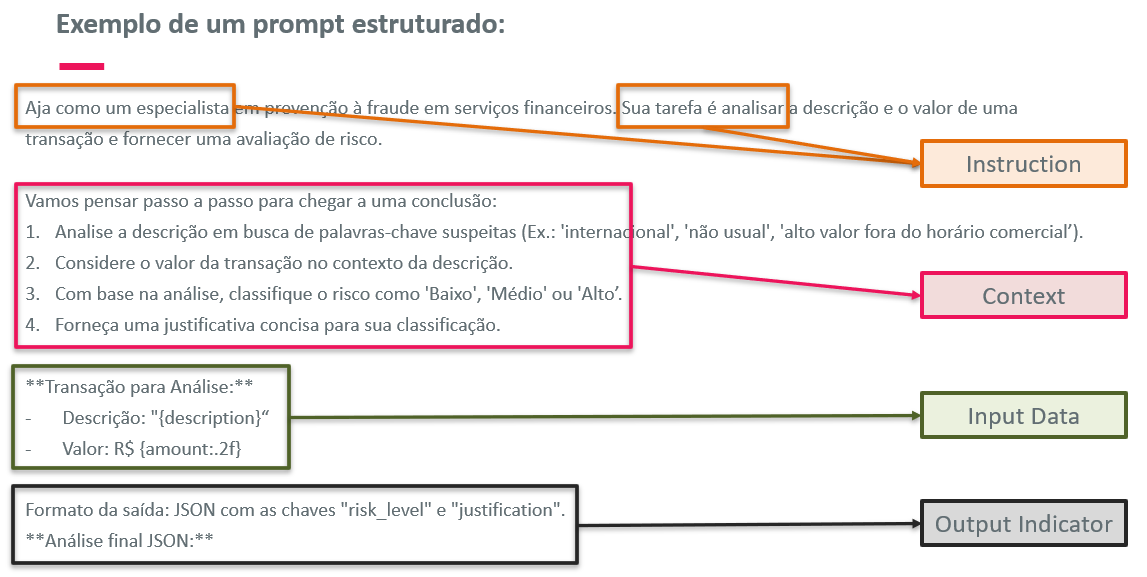

###**5.2 - Consolidado de boas práticas**

1. **Defina uma Persona (Set a Persona / Role Prompting):** Atribuir um papel específico à IA (ex.: especialista, professor, analista de dados) direciona estilo e foco da resposta, ou seja, aciona uma determinada "caixa de contexto".
  - Exemplo de prompt:
    ```
    Você é um agente de suporte ao cliente. Responda à seguinte reclamação em um tom calmo e prestativo.
    ```
  - Comentário: Funciona muito bem em tarefas relacionais (atendimento, consultoria, análises, etc.), mas pode ser redundante em tarefas técnicas puras (ex.: gerar código Python por exemplo).

2. **Seja Claro e Específico (Be Clear and Specific):** Prompts vagos = respostas imprecisas. Forneça contexto relevante (exemplos, restrições, instruções detalhadas).
  - Prompt:
    ```
    Reescreva esta mensagem em um tom persuasivo para um comprador empresarial.
    ```
  - Comentário: Cuidado com o excesso de contexto. Um prompt longo demais pode confundir o modelo. Prefira clareza e concisão.

3. **Use Exemplos (Few-shot Prompting):** Mostrar exemplos de entrada e saída guia o modelo sobre o padrão esperado e pode aumentar significativamente o nível da resposta do modelo (veja o paper Language Models are Few-Shot Learners).
  - Exemplo de prompt:
    ```
    Classifique as frases como Positivo, Negativo ou Neutro.
      - Exemplo: "O site é lento" -> Negativo
      - Exemplo: "Adorei a interface" -> Positivo
    Agora classifique: "O produto é bom, mas a entrega foi demorada."
    ```
  - Comentário: Poucos exemplos podem ajudar o modelo a aprender o padrão, mas se você usar muitos exemplos, o prompt pode ficar pesado e consumir tokens desnecessários.
  - Dica: Diga ao modelo para não usar os exemplos em suas respostas (se for o caso).

4. **Diga o que Não Fazer (Tell AI What Not to Do):** Definir limites claros evita alucinações, respostas irrelevantes e inadequadas.
  - Exemplo de rompt:
    ```
    Resuma o relatório financeiro em anexo em menos de 200 palavras.
    Não inclua contexto introdutório ou comparações históricas.
    Concentre-se apenas nos números de receita e na análise de custos do 4º trimestre.
    ```
  - Comentário: Parte essencial de um prompt. “Negative prompting” ajuda a reduzir o viés criativo indesejado.
    - Outro exemplo: `“Não invente informações que não estão no documento.”`

5. **Especifique um Público (Specify an Audience):** Especificar um público-alvo dá estrutura e direção ao prompt. Isso ajuda a IA a moldar o tom, o estilo e o nível de detalhe da resposta.
  - Exemplo de prompt:
    ```
    Resuma este relatório de marketing para um chefe de vendas em 3 tópicos, destacando as principais tendências de receita.
    ```
  - Comentário: Nem sempre “especificar público” é suficiente. É importante também definir o tom (formal, persuasivo, técnico) e o nível de detalhe. Caso contrário, a resposta pode vir superficial demais.

6. **Compreenda a Tarefa (Comprehend the Task at Hand):** Antes de escrever o prompt, entenda o objetivo e o nível de profundidade esperado. Prompts são um processo iterativo: raramente o primeiro será perfeito.
  - Exemplo de prompt:
    ```
    Resuma o desempenho mensal de vendas de todos os gerentes regionais.
    Destaque qualquer região onde as vendas tenham caído mais de 15% em relação ao mês anterior.
    ```
  - Comentário: Pense passo a passo, pedindo que a IA explique como chegar à conclusão, isso pode aumentar a confiabilidade da reposta.
  - Dica: Peça para a IA te falar como chegou nessa conclusão.

7. **Divida Tarefas Complexas (Break Down Complex Tasks):** Divida a tarefa em etapas menores e claras. Isso ativa o mecanismo de raciocínio do modelo (**Chain-of-Thought (CoT) Prompting** implícito).
  - Exemplo de prompt:
    ```
    Execute as seguintes tarefas em ordem:
      1. Leia o arquivo CSV com dados de vendas.
      2. Calcule o faturamento total e o ticket médio.
      3. Identifique os 3 produtos mais vendidos.
    ```
  - Comentário: Funciona muito bem com tarefas analíticas. Mas para automações maiores, prefira agentes (como LangChain e AutoGPT), que conseguem executar várias etapas de forma autônoma.

8. **Remova Ambiguidade (Remove Ambiguity):** Evite palavras vagas, suposições e redundâncias. Use termos exatos e bem definidos.
  - Exemplo de rompt:
    ```
    Extraia os seguintes campos do formulário de pedido de compra: Nome do Cliente, ID do Pedido, Produto, Quantidade e Preço Total.
    Retorne o resultado em formato JSON com os nomes dos campos como chaves.
    ```
  - Comentário: É uma excelente prática. Porém, modelos podem inventar valores ausentes em tarefas de extração. Sempre valide a saída antes de usar em processos críticos.

9. **Estruture por Prioridade (Structure Prompts by Priority):** Liste primeiro as ações principais, depois exceções, e por último restrições.
  - Exemplo de prompt:
    ```
    1. Você é um assistente de análise de negócios que analisa dados de vendas mensais em formato CSV.
    2. Comece calculando a receita total, o número de transações e o valor médio do pedido.
    3. Em seguida, agrupe as vendas por “categoria de produto” e calcule o total de vendas e receita para cada categoria.
    4. Destaque qualquer categoria de produto em que a receita mensal caiu mais de 20% em comparação ao mês anterior.
    5. Se alguma entrada tiver valores ausentes, sinalize em “Problemas de dados”.
    6. Não inclua previsões; analise apenas dados históricos.
    7. Retorne em JSON com chaves: resumo, detalhamento e problemas.
    ```
  - Comentário: Este tipo de prompt estruturado é muito útil em engenharia de dados, quando queremos saídas programaticamente integráveis.

10. **Especifique o Formato de Saída (Specify the Output Format):** Defina claramente como o modelo deve entregar a resposta (JSON, CSV, Markdown, etc.).
  - Exemplo de prompt:
    ```
    Resposta apenas a saída delimitada com ";" no formato CSV com cabeçalhos dos campos e valores.
    Não inclua parênteses ou aspas.
    ```
  - Comentário: Boa prática, mas modelos podem quebrar o formato em respostas longas. Uma dica é pedir: “Valide se o JSON está bem formatado antes de responder.” Dê preferencia por usar funções de `parser` dos modelos ou frameworks.


###**5.3 - Dicas de bônus e não menos importantes:**

- **Formatação em Markdown (Markdown formatting):** Markdown organiza o texto de forma clara, facilitando a interpretação do modelo. Essa formatação ajuda o LLM a entender a hierarquia das informações (títulos, listas, tabelas, códigos etc.).
  - Exemplo de prompt:
  ```
    ## Tarefa
    Explique como funciona o processamento de dados no Apache Spark.

    ## Formato da Resposta
    - Explique em tópicos
    - Inclua um exemplo em Python
    - Finalize com uma analogia simples
  ```
  - Comentário: Combine múltiplas boas práticas, gerando saídas mais confiáveis e úteis, porém atenção o prompt fica mais longo e mais caro em termos de tokens.

- **Escreva seu Prompt em Inglês (Write in English):** O treinamento dos modelos de linguagem são majoritariamente em inglês, logo eles vão entender melhor em inglês.
  - Exemplo de prompt:
    ```
    You are a customer support agent. Please respond to the following complaint in a calm, helpful tone, and in Portuguese (PT-BR).
    ```
  - Comentário: Porém, os modelos de linguagem são bons em traduzir, então se deseja uma resposta em uma linguagem específica, peça para ele responder nessa linguagem.

Referências:
- [Prompt Engineering Best Practices You Should Know](https://www.astera.com/type/blog/prompt-engineering-best-practices/)
- [Paper - Language Models are Few-Shot Learners](https://arxiv.org/pdf/2005.14165)
- [Prompt Engineering Guide](https://www.promptingguide.ai/)
- [Paper - Chain-of-Thought Prompting Elicits Reasoning in Large Language Models](https://arxiv.org/pdf/2201.11903)
